In [3]:
import math
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

#多头注意力
#使多个头并行计算
def transpose_qkv(X, num_heads):
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    '''逆转transpose_qkv函数的操作'''
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

#选择缩放点积注意力作为每一个注意力头
class MultiHeadAttention(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens, num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = d2l.DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        #分别对queries，keys，values做线性变换和转置重塑
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        #处理有效长度
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)

        #计算注意力
        output = self.attention(queries, keys, values, valid_lens)
        #逆变换
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

In [4]:
#测试
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens, num_hiddens, num_heads, 0.5)
attention.eval()
batch_size, num_queries, num_kvpairs, valid_lens = 2, 4, 6, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
print(attention(X, Y, Y, valid_lens).shape)

torch.Size([2, 4, 100])


In [5]:
#Transformer

#基于位置的前馈网络
#作用：在Transformer的编码器和解码器中，每个注意力层之后都跟着一个全连接前馈网络。它对每个位置的向量独立进行相同的非线性变换，增加模型的表达能力
class PositionWiseFFN(nn.Module):
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs, **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        #第一层线性变换
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        #非线性激活
        self.relu = nn.ReLU()
        #第二层线性变换
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [6]:
#改变张量的最里层维度的尺寸
ffn = PositionWiseFFN(4, 4, 8)
ffn.eval()
print(ffn(torch.ones((2, 3, 4)))[0])

tensor([[-0.4212, -0.2880, -0.0621,  0.4511, -0.1785, -0.2288,  0.2494, -0.4305],
        [-0.4212, -0.2880, -0.0621,  0.4511, -0.1785, -0.2288,  0.2494, -0.4305],
        [-0.4212, -0.2880, -0.0621,  0.4511, -0.1785, -0.2288,  0.2494, -0.4305]],
       grad_fn=<SelectBackward0>)


In [7]:
#对比不同维度的层归一化和批量归一化的效果
ln = nn.LayerNorm(2)
bn = nn.BatchNorm1d(2)
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)
print('layer norm:', ln(X))
print('batch norm:', bn(X))

layer norm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>)
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [8]:
#使用残差连接和层归一化
class AddNorm(nn.Module):
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [9]:
#加法操作后输出张量的形状相同
add_norm = AddNorm([3, 4], 0.5)
add_norm.eval()
print(add_norm(torch.ones((2,3,4)), torch.ones((2,3,4))).shape)

torch.Size([2, 3, 4])


In [12]:
#实现编码器中的一个层
class EncoderBlock(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout, use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [13]:
#Transformer编码器中的任何层都不会改变其输入的形状
X = torch.ones((2, 100, 24))
valid_lens = torch.tensor([3,2])
encoder_blk = EncoderBlock(24,24,24,24,[100,24],24,48,8,0.5)
encoder_blk.eval()
print(encoder_blk(X, valid_lens).shape)

torch.Size([2, 100, 24])


In [19]:
#Transformer编码器
class TransformerEncoder(d2l.Encoder):
    def __init__(self, vocab_size, key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(
                'block' + str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, dropout, use_bias)
            )

    def forward(self, X, valid_lens, *args):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
        return X

In [20]:
#创建一个两层的Transformer编码器
encoder = TransformerEncoder(200,24,24,24,24,[100,24],24,48,8,2,0.5)
encoder.eval()
print(encoder(torch.ones((2,100), dtype=torch.long), valid_lens).shape)

torch.Size([2, 100, 24])


In [21]:
#解码器

#Transformer解码器也是由多个相同的层组成
class DecoderBlock(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        #解码器中第i个块（记录当前块的编号，用于管理缓存）
        self.i = i
        #掩码自注意力
        self.attention1 = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        #交叉注意力
        self.attention2 = d2l.MultiHeadAttention(num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
        #输入与状态解包
        enc_outputs, enc_valid_lens = state[0], state[1]
        #维护key-value缓存
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        #生成解码器自注意力的有效长度掩码
        if self.training:
            batch_size, num_steps, _ = X.shape
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device
            ).repeat(batch_size, 1)
        else:
            dec_valid_lens = None

        #掩码自注意力+AddNorm
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        #交叉注意力+AddNorm
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        #前馈网络+AddNorm
        return self.addnorm3(Z, self.ffn(Z)), state

In [22]:
#编码器和解码器的特征维度都是num_hiddens
decoder_blk= DecoderBlock(24,24,24,24,[100,24],24,48,8,0.5,0)
decoder_blk.eval()
X = torch.ones((2,100,24))
state = [encoder_blk(X, valid_lens), valid_lens, [None]]
print(decoder_blk(X, state)[0].shape)

torch.Size([2, 100, 24])


In [23]:
#Transformer解码器
class TransformerDecoder(d2l.AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = d2l.PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module(
                'block' + str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, dropout, i)
            )
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None]*self.num_layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None]*len(self.blks) for _ in range(2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights

        return self.dense(X), state

    def attention_weights(self):
        return self._attention_weights

In [25]:
#粘贴必要函数
def sequence_mask(X, valid_len, value=0):
    '''在序列中屏蔽不相关的项'''
    #获取最大长度（X的第二个维度大小）
    maxlen = X.size(1)
    #构造掩码向量
    mask = torch.arange(
        (maxlen), dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    #替换无效位置的值
    X[~mask] = value
    return X

X = torch.tensor([[1,2,3],
                  [4,5,6]])
print(sequence_mask(X, torch.tensor([1,2])))

class MaskedSoftmaxCEloss(nn.CrossEntropyLoss):
    '''带遮蔽的softmax交叉熵损失函数'''
    def forward(self, pred, label, valid_len):
        #构造权重掩码
        weights = torch.ones_like(label)
        weights = sequence_mask(weights, valid_len)
        #修改reduction模式，防止默认损失求平均
        self.reduction = 'none'
        #计算未加权的损失（调用父类的前向传播方法）
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        #加权平均
        weighted_loss = (unweighted_loss * weights).mean(dim=1)
        return weighted_loss

def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    '''训练序列到序列模型'''
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if 'weight' in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCEloss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss',
                            xlim=[10,num_epochs])
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)
        for batch in data_iter:
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            bos = torch.tensor([tgt_vocab['<bos>']]*Y.shape[0],device=device).reshape(-1,1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)
            Y_hat = net(X, dec_input, X_valid_len)
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        if (epoch + 1) % 10 == 0:
            animator.add(epoch+1, (metric[0]/metric[1],))
    print(f'loss {metric[0]/metric[1]:.3f}, {metric[1]/timer.stop():.3f}'
          f'tokens/sec on {str(device)}')

tensor([[1, 0, 0],
        [4, 5, 0]])


loss 0.028, 13838.993tokens/sec on cuda:0
None


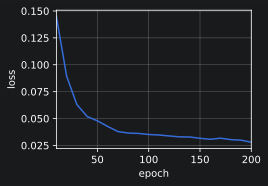

In [26]:
#训练
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs, device = 0.005, 200, d2l.try_gpu()
ffn_num_input, ffn_num_hiddens ,num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)
encoder = TransformerEncoder(len(src_vocab), key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, num_layers, dropout)
decoder = TransformerDecoder(len(tgt_vocab), key_size, query_size, value_size, num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens, num_heads, num_layers, dropout)
net = d2l.EncoderDecoder(encoder, decoder)
print(train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device))

In [27]:
#将几个英语句子翻译成法语
engs = ['go .','i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
for eng, fra in zip(engs, fras):
    translation, attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => rentre chez <unk> ., bleu 0.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est calme ., bleu 1.000
i'm home . => je suis chez moi ., bleu 1.000
